In [1]:
using Pkg
Pkg.activate("./DOPE_working.jl")
using DOPE
using DelimitedFiles

  Activating project at `C:\Users\freye\OneDrive\Documents\Felipe\projects\OpenElectrons\DOPE_working.jl`


In [2]:
using Interpolations
using KadanoffBaym:wigner_transform
using FFTW

import PyPlot as plt

In [3]:
plt.rc("text", usetex=true)
plt.rc("font", family="serif")
plt.rc("text.latex", preamble=raw"\usepackage{amsmath}")
fs = 21
plt.rc("font", size=fs)
plt.rc("axes", labelsize=fs, titlesize=fs)
plt.rc("xtick", labelsize=fs)
plt.rc("ytick", labelsize=fs)
plt.rc("legend", fontsize=fs)

letter = ["("*string(c)*")" for c in 'a':'z'];

In [4]:
dir_path = joinpath("DOPE_v3","projects","2026-04-14-structured-chain-glgg-t60-b0","full_t60","data","raw")
file1 = "run_003_T0p050_alpha0p500_eta0p050_pc1p000_b0p000.jls"
file2 = "run_006_T0p050_alpha0p500_eta0p500_pc1p000_b0p000.jls"

raw_path1 = joinpath(dir_path, file1)
raw_path2 = joinpath(dir_path, file2)

raw1 = load_raw_output(raw_path1)
raw2 = load_raw_output(raw_path2)# Dict
keys(raw1)

KeySet for a Dict{String, Any} with 8 entries. Keys:
  "weights"
  "k_grid"
  "GL"
  "GG"
  "times"
  "params"
  "metadata"
  "p_grid"

In [5]:
ts1 = raw1["times"]
GL1 = raw1["GL"]
GG1 = raw1["GG"]
ks1 = raw1["k_grid"];

ts2 = raw2["times"]
GL2 = raw2["GL"]
GG2 = raw2["GG"]
ks2 = raw2["k_grid"];

In [6]:
function hann_window(tau, tmax)
    return 0.5 * (1 + cos(π * tau / tmax))
end

hann_window (generic function with 1 method)

In [7]:
equitimes = 0:0.1:ts1[end]

GL1_itp = interpolate((ks1,ts1,ts1), GL1[:,1,1,:,:], Gridded(Linear()))
GG1_itp = interpolate((ks1,ts1,ts1), GG1[:,1,1,:,:], Gridded(Linear()));

equiGL1 = [GL1_itp(k,t1,t2) for k in ks1, t1 in equitimes, t2 in equitimes]
equiGG1 = [GG1_itp(k,t1,t2) for k in ks1, t1 in equitimes, t2 in equitimes];

GL2_itp = interpolate((ks2,ts2,ts2), GL2[:,1,1,:,:], Gridded(Linear()))
GG2_itp = interpolate((ks2,ts2,ts2), GG2[:,1,1,:,:], Gridded(Linear()));

equiGL2 = [GL2_itp(k,t1,t2) for k in ks2, t1 in equitimes, t2 in equitimes]
equiGG2 = [GG2_itp(k,t1,t2) for k in ks2, t1 in equitimes, t2 in equitimes];

In [8]:
hann_mask = [hann_window(t1-t2, equitimes[end]) for k in ks1, t1 in equitimes, t2 in equitimes];
exp_mask = [exp(-1e-3*abs(t1-t2)) for k in ks1, t1 in equitimes, t2 in equitimes];

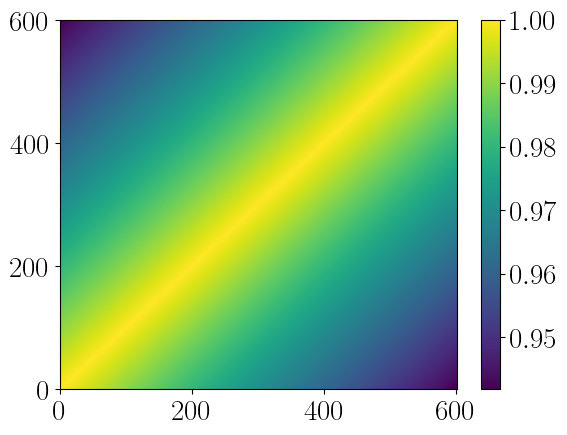

luatex: security risk: running with elevated privileges


PyObject <matplotlib.colorbar.Colorbar object at 0x000001C01E744D90>

In [9]:
plt.pcolormesh(exp_mask[1,:,:], vmax=1)
plt.colorbar()

In [10]:
GL1wig = []
GG1wig = []

freqs = []

@inbounds for k in 1:length(ks1)
    
    if k%10==0 println("k=$k") end
    
    w_transf, aux = wigner_transform(equiGL1[k,:,:] .* hann_mask[k,:,:], ts=equitimes, fourier=true)
    # w_transf, aux = wigner_transform(equiGL[k,:,:], ts=equitimes, fourier=true)
        
    push!(GL1wig, w_transf)
    
    w_transf, aux = wigner_transform(equiGG1[k,:,:] .* hann_mask[k,:,:], ts=equitimes, fourier=true)
    # w_transf, aux = wigner_transform(equiGG[k,:,:], ts=equitimes, fourier=true)
        
    push!(GG1wig, w_transf)
    
    push!(freqs, aux)
end

freqs, Ts = freqs[end]
GL1wig = permutedims(stack(GL1wig, dims=3), (2,1,3))
GG1wig = permutedims(stack(GG1wig, dims=3), (2,1,3));

k=10
k=20
k=30
k=40
k=50
k=60
k=70
k=80
k=90
k=100


In [11]:
GL2wig = []
GG2wig = []

freqs = []

@inbounds for k in 1:length(ks2)
    
    if k%10==0 println("k=$k") end
    
    w_transf, aux = wigner_transform(equiGL2[k,:,:] .* hann_mask[k,:,:], ts=equitimes, fourier=true)
    # w_transf, aux = wigner_transform(equiGL[k,:,:], ts=equitimes, fourier=true)
        
    push!(GL2wig, w_transf)
    
    w_transf, aux = wigner_transform(equiGG2[k,:,:] .* hann_mask[k,:,:], ts=equitimes, fourier=true)
    # w_transf, aux = wigner_transform(equiGG[k,:,:], ts=equitimes, fourier=true)
        
    push!(GG2wig, w_transf)
    
    push!(freqs, aux)
end

freqs, Ts = freqs[end]
GL2wig = permutedims(stack(GL2wig, dims=3), (2,1,3))
GG2wig = permutedims(stack(GG2wig, dims=3), (2,1,3));

k=10
k=20
k=30
k=40
k=50
k=60
k=70
k=80
k=90
k=100


In [12]:
spectral1 = GG1wig .- GL1wig
keldysh1 = GG1wig .+ GL1wig
fdist1 = GL1wig ./ spectral1;

spectral2 = GG2wig .- GL2wig
keldysh2 = GG2wig .+ GL2wig
fdist2 = GL2wig ./ spectral2;

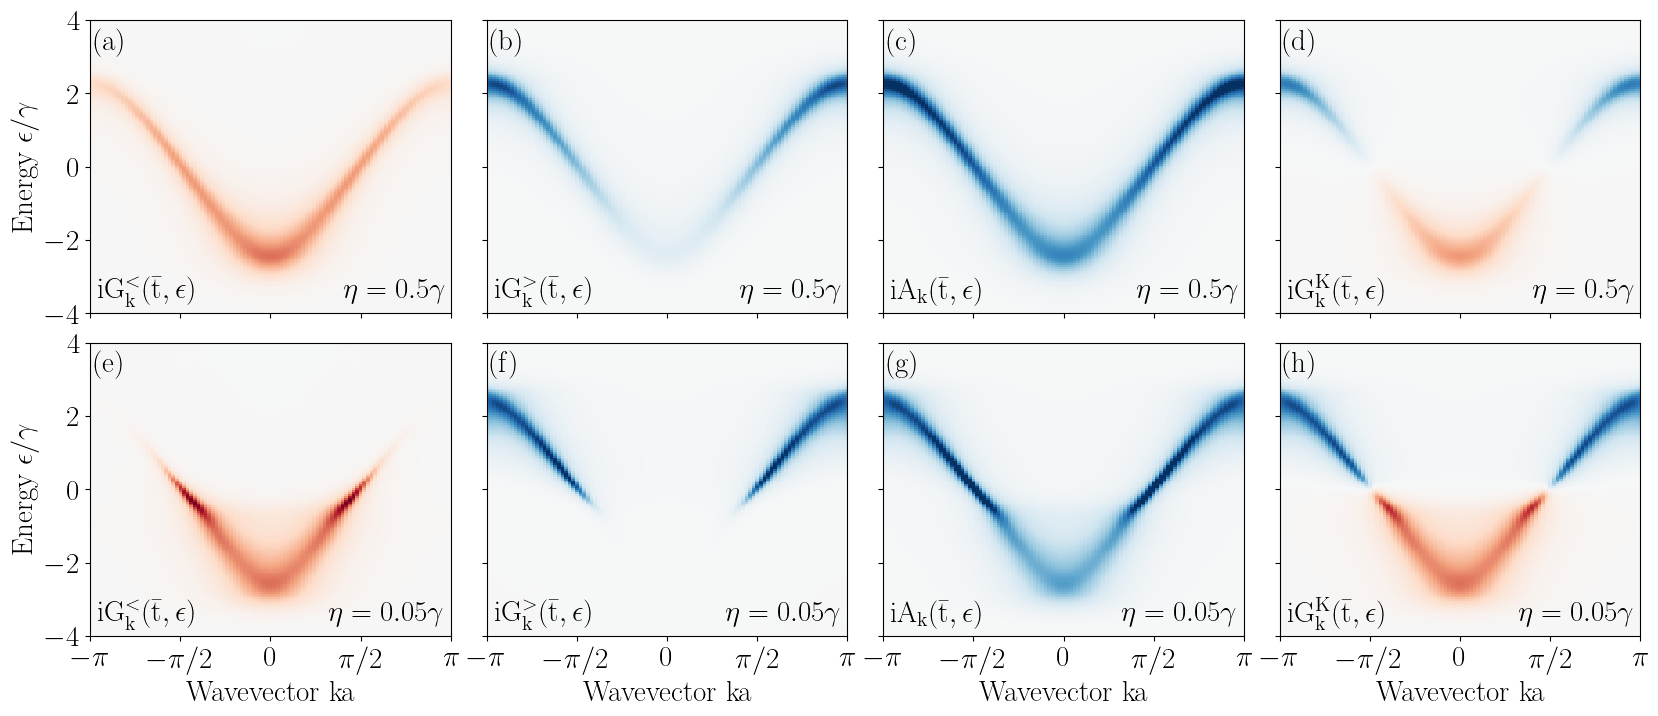

In [148]:
fig, ax= plt.subplots(nrows = 2, ncols = 4, sharex="col", sharey="row", figsize=(20,8))
fig.subplots_adjust(wspace=0.1, hspace=0.1)

tsnap=200

clim = 7

ax[2,1].pcolormesh(ks1, freqs, real.(1im .* GL1wig[tsnap,:,:]), vmin=-clim, vmax=clim, cmap="RdBu")
ax[2,2].pcolormesh(ks1, freqs, real.(1im .* GG1wig[tsnap,:,:]), vmin=-clim, vmax=clim, cmap="RdBu")

# COLORBAR!!!!

ax[2,3].pcolormesh(ks1, freqs, real.(1im .* spectral1[tsnap,:,:]), vmin=-clim, vmax=clim, cmap="RdBu")
ax[2,4].pcolormesh(ks1, freqs, real.(1im .* keldysh1[tsnap,:,:]), vmin=-clim, vmax=clim, cmap="RdBu")

ax[1,1].pcolormesh(ks2, freqs, real.(1im .* GL2wig[tsnap,:,:]), vmin=-clim, vmax=clim, cmap="RdBu")
ax[1,2].pcolormesh(ks2, freqs, real.(1im .* GG2wig[tsnap,:,:]), vmin=-clim, vmax=clim, cmap="RdBu")

ax[1,3].pcolormesh(ks2, freqs, real.(1im .* spectral2[tsnap,:,:]), vmin=-clim, vmax=clim, cmap="RdBu")
ax[1,4].pcolormesh(ks2, freqs, real.(1im .* keldysh2[tsnap,:,:]), vmin=-clim, vmax=clim, cmap="RdBu")

# ax[3].plot(ks, 2*abs.(ks).-2.8, "g--")

panel_order = [1,5,2,6,3,7,4,8]
gflabel = [raw"$\rm iG^<_k(\bar t,\epsilon)$", raw"$\rm iG^>_k(\bar t,\epsilon)$", 
    raw"$\rm iA_k(\bar t,\epsilon)$", raw"$\rm iG^K_k(\bar t,\epsilon)$"]
gflabel = vcat(gflabel,gflabel)
for (i,a) in enumerate(ax)
    a.text(x=0.01, y=0.9, s=letter[panel_order[i]], transform=a.transAxes, fontsize=fs)
    a.text(x=0.02, y=0.05, s=gflabel[panel_order[i]], transform=a.transAxes, fontsize=fs)
    if isodd(i) a.text(x=0.7, y=0.05, s=raw"$\rm \eta=0.5\gamma$", transform=a.transAxes, fontsize=fs)
    else a.text(x=0.66, y=0.05, s=raw"$\rm \eta=0.05\gamma$", transform=a.transAxes, fontsize=fs) end

    if i<=2 a.set_ylabel(raw"Energy $\rm \epsilon/\gamma$", fontsize=fs) end
    if i%2==0 a.set_xlabel(raw"Wavevector $\rm ka$", fontsize=fs) end
    a.set_xlim(-π, π)
    a.set_xticks(-π:π/2:π, [raw"$-\pi$", raw"$-\pi/2$", "0", raw"$\pi/2$", raw"$\pi$"])
    a.set_ylim(-4,4)
end

fig.align_labels()

# fig.savefig("chain_spectral.pdf", bbox_inches="tight")

In [46]:
dos1 = dropdims(sum(spectral1, dims=3), dims=3)./ 101
occs1 = dropdims(sum(GL1wig, dims=3), dims=3) ./ 101

fdist1 = occs1 ./ dos1;

dos2 = dropdims(sum(spectral2, dims=3), dims=3)./ 101
occs2 = dropdims(sum(GL2wig, dims=3), dims=3) ./ 101

fdist2 = occs2 ./ dos2;

C:\Program Files\Python311_julia\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Program Files\Python311_julia\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


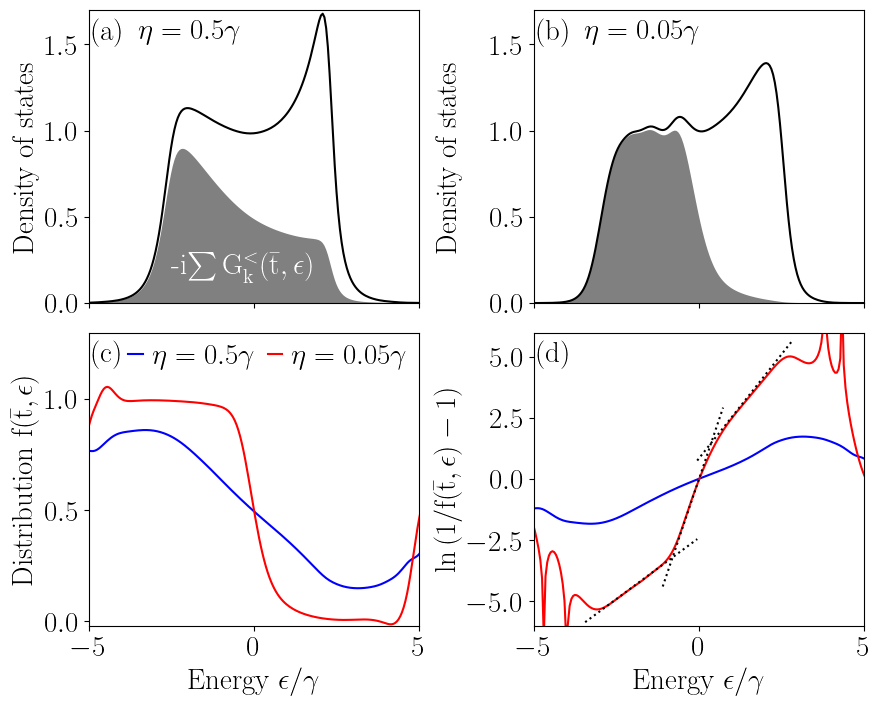

In [149]:
fig, ax= plt.subplots(nrows = 2, ncols = 2, sharex="col", figsize=(10,8))
fig.subplots_adjust(wspace=0.35, hspace=0.1)

ax[1,1].plot(freqs, -imag(dos2[tsnap,:]), "k")
ax[1,1].fill(freqs, imag(occs2[tsnap,:]), "grey", label=raw"-i$\rm \sum G^<_k(\bar t, \epsilon)$")

ax[1,1].set_ylim(0,1.7)
ax[1,1].set_ylabel(raw"Density of states", fontsize=fs)
# ax[1,1].legend(frameon=false, handlelength=0.75, handletextpad=0.5, loc="upper left", bbox_to_anchor=[0.05,1.05])
ax[1,1].text(x=0.25, y=0.1, s=raw"-i$\rm \sum G^<_k(\bar t, \epsilon)$", transform=ax[1,1].transAxes, fontsize=fs, color="w")
ax[1,1].text(x=0.15, y=0.9, s=raw"$\rm \eta=0.5\gamma$", transform=ax[1,1].transAxes, fontsize=fs)

ax[1,2].plot(freqs, -imag(dos1[tsnap,:]), "k")
ax[1,2].fill(freqs, imag(occs1[tsnap,:]), "grey")

ax[1,2].set_ylim(0,1.7)
ax[1,2].set_ylabel(raw"Density of states", fontsize=fs)
ax[1,2].text(x=0.15, y=0.9, s=raw"$\rm \eta=0.05\gamma$", transform=ax[1,2].transAxes, fontsize=fs)

ax[2,1].plot(freqs, -real(fdist2[tsnap,:]), "b", label=raw"$\eta = 0.5 \gamma$")
ax[2,1].plot(freqs, -real(fdist1[tsnap,:]), "r", label=raw"$\eta = 0.05 \gamma$")
# ax[2].axvline(-3, color="k")
# ax[2].axvline(3, color="k")
ax[2,1].legend(frameon=false, handlelength=0.5, handletextpad=0.3, ncol=2, columnspacing=0.5, 
    loc="upper left", bbox_to_anchor=[0.04,1.05])

ax[2,1].set_ylim(-0.02,1.3)
ax[2,1].set_ylabel(raw"Distribution $\rm f(\bar t, \epsilon)$", fontsize=fs)

ax[2,2].plot(freqs, log.(-1 ./ fdist2[tsnap,:] .- 1), "b")
ax[2,2].plot(freqs, log.(-1 ./ fdist1[tsnap,:] .- 1), "r")
ax[2,2].plot(freqs[280:315], 4*freqs[280:315], "k", ls=":")
ax[2,2].plot(freqs[300:355], 1.7*(freqs[300:355] .+ 0.5), "k", ls=":")
ax[2,2].plot(freqs[235:300], 1.0*(freqs[235:300] .- 2.4), "k", ls=":")

# ax[3].axvline(-3, color="k")
# ax[3].axvline(3, color="k")

ax[2,2].set_ylim(-6,6)
ax[2,2].set_ylabel(raw"$\rm \ln \left(1/f(\bar t, \epsilon)-1 \right)$", fontsize=fs)


# ax[3].plot(freqs, freqs * 5, "r--")
# ax[3].plot(freqs, (freqs .+ 0.7) * 1.6, "r--")
# ax[3].plot(freqs, (freqs .- 2.1) * 1.05, "r--")

# for (i, a) in enumerate(ax)
#     a.set_xlim(-5,5)
# end

panel_order = [1,3,2,4]
for (i,a) in enumerate(ax)
    a.text(x=0.01, y=0.9, s=letter[panel_order[i]], transform=a.transAxes, fontsize=fs)
    
    if iseven(i) a.set_xlabel(raw"Energy $\rm \epsilon/\gamma$", fontsize=fs) end
    a.set_xlim(-5, 5)
end

fig.align_labels()

# fig.savefig("chain_dist.pdf", bbox_inches="tight")